# Featurizing the tags in TEI-XML documents

The idea is that if we feature-ize tags in TEI-XML documents we can more or less get a picture of the "perspective" or "genres" of digital scholarly editions (DSEs).

First things first. Figuring out how to get the tags. 

In [3]:
# Some basic code generated with the help of ChatGPT works pretty well.

from xml.parsers import expat

def tag_text_positions(xml_string):

    '''
    Parses an XML file, records for each tag the start and end position, 
    ignoring any other tags. Effectively it tells you at what positions tags 
    start and end if all tags would have been omitted from the text. Note that
    this is *not* exact, as indentation is counted as part of the text while
    it might just be ignorable whitespace from pretty printing XML.
    
    Args:
        xml_string: string representing an XML document.
    
    Returns:
        a list containing dictionaries: 
            [ 
                { 
                    'tag': <string>the tag name, 
                    'start': <int>start position,
                    'end': <int>end position
                }, … 
            ]
    '''
    
    parser = expat.ParserCreate()

    results = []
    stack = []

    text_pos = 0  # position in tag-stripped text

    def start(name, attrs):
        nonlocal text_pos
        stack.append({
            "tag": name,
            "start": text_pos
        })

    def end(name):
        nonlocal text_pos
        item = stack.pop()
        item["end"] = text_pos
        results.append(item)

    def char_data(data):
        nonlocal text_pos
        text_pos += len(data)

    parser.StartElementHandler = start
    parser.EndElementHandler = end
    parser.CharacterDataHandler = char_data

    parser.Parse(xml_string)

    return results

In [4]:
file_path_H2 = 'faust-xml/xml/transcript/gsa/391098/391098.xml'
with open( file_path_H2, 'r' ) as xml_file:
    xml_string = xml_file.read()
tag_pos = tag_text_positions( xml_string )
tag_pos[1:5]

[{'tag': 'title', 'start': 52, 'end': 80},
 {'tag': 'author', 'start': 93, 'end': 115},
 {'tag': 'resp', 'start': 144, 'end': 161},
 {'tag': 'name', 'start': 177, 'end': 192}]

Let's put that in a Pandas data frame for analysis.

In [5]:
# !pip install pandas
import pandas

In [6]:
tp_df = pandas.DataFrame( tag_pos )
tp_df

,tag,start,end
0,title,34,39
1,title,52,80
2,author,93,115
3,resp,144,161
4,name,177,192
...,...,...,...
17211,body,821723,823002
17212,text,821710,823012
17213,group,18381,823019
17214,text,18374,823023


How many unique tags?

In [7]:
tp_df['tag'].unique()

<StringArray>
[          'title',          'author',            'resp',            'name',
         'orgName',        'respStmt',       'titleStmt',       'publisher',
            'idno',            'date',         'licence',    'availability',
 'publicationStmt',      'repository',   'altIdentifier',    'msIdentifier',
          'msDesc',      'sourceDesc',        'fileDesc',          'change',
      'listChange',        'creation',             'ptr',       'transpose',
   'listTranspose',        'handNote',       'handNotes',     'profileDesc',
        'charName',            'desc',         'mapping',            'char',
        'charDecl',    'encodingDesc',    'revisionDesc',       'teiHeader',
              'pb',       'titlePart',        'docTitle',       'titlePage',
              'lb',               'g',             'add',           'front',
            'head',              'hi',           'stage',         'speaker',
               'l',            'orig',              'lg',     

How are these distributed over the actual tags/elements?

In [8]:
# !pip install matplotlib
import matplotlib.pyplot as plt

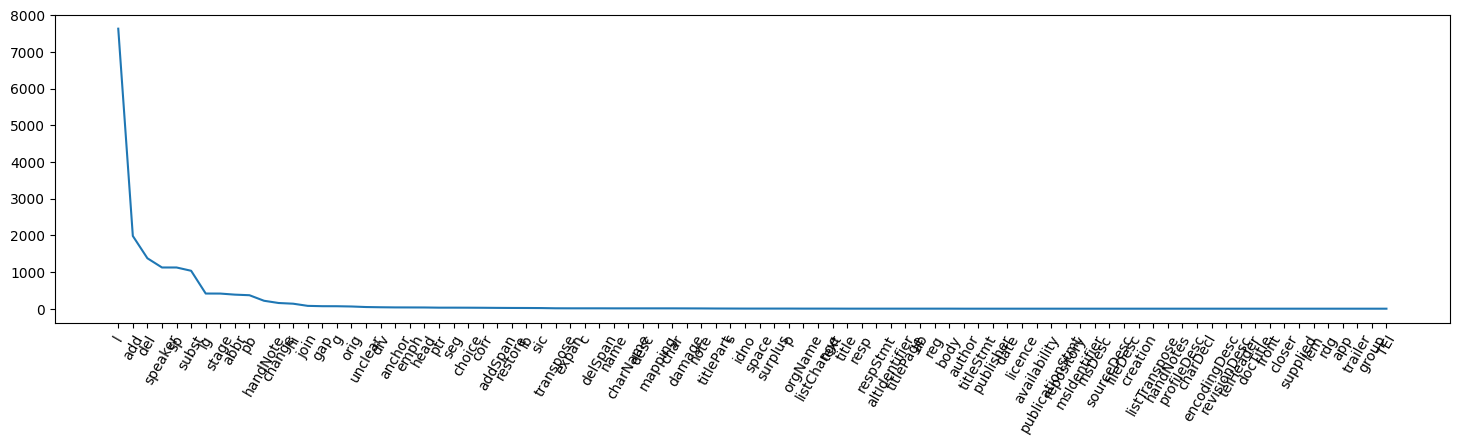

In [9]:
fig, ax = plt.subplots( figsize=(18,4))
ax.plot( tp_df['tag'].value_counts() )
ax.tick_params(axis='x', labelrotation=60)

Whoops, a number of tags have exactly the same count, and so their labels clutter up. We need some Pandas magic to fix this.

In [10]:
# Turn value_counts() into a proper and actually useful DataFrame.
tag_counts = pandas.DataFrame( tp_df['tag'].value_counts().rename_axis('tag').reset_index(name='counts') )

# Now group by 'counts' and for the tags you put into one group concatenate their names.
tpc_df = tag_counts.groupby( 'counts' )['tag'].apply( lambda s: ", ".join( sorted( map( str, s ) ) ) )
tpc_df.head(10)


counts
1     TEI, app, author, availability, charDecl, clos...
2     ab, altIdentifier, body, reg, resp, respStmt, ...
3                             listChange, orgName, text
4                               idno, p, space, surplus
5                                                     s
6                                             titlePart
8                                                  note
9                                                damage
10                  char, charName, desc, mapping, name
11                                    c, delSpan, expan
Name: tag, dtype: str

Okay, that works, but the label for the 1 count has 30 tag names…

In [11]:
len( tpc_df[1].split(',') )

30

Let's put these across two lines at least.

In [12]:
labels = tpc_df[1].split(',')
multiline_label = labels.pop(0)
for idx, tag in enumerate( labels ):
    multiline_label += f',{tag}'
    if ( (idx + 1) % 7 == 0 ):
        multiline_label += '\n'
multiline_label

'TEI, app, author, availability, charDecl, closer, creation, date\n, docTitle, encodingDesc, fileDesc, front, group, handNotes, lem\n, licence, listTranspose, msDesc, msIdentifier, profileDesc, publicationStmt, publisher\n, rdg, repository, revisionDesc, sourceDesc, supplied, teiHeader, titleStmt\n, trailer'

In [13]:
x = tpc_df.values
x[0] = multiline_label
y = tpc_df.index

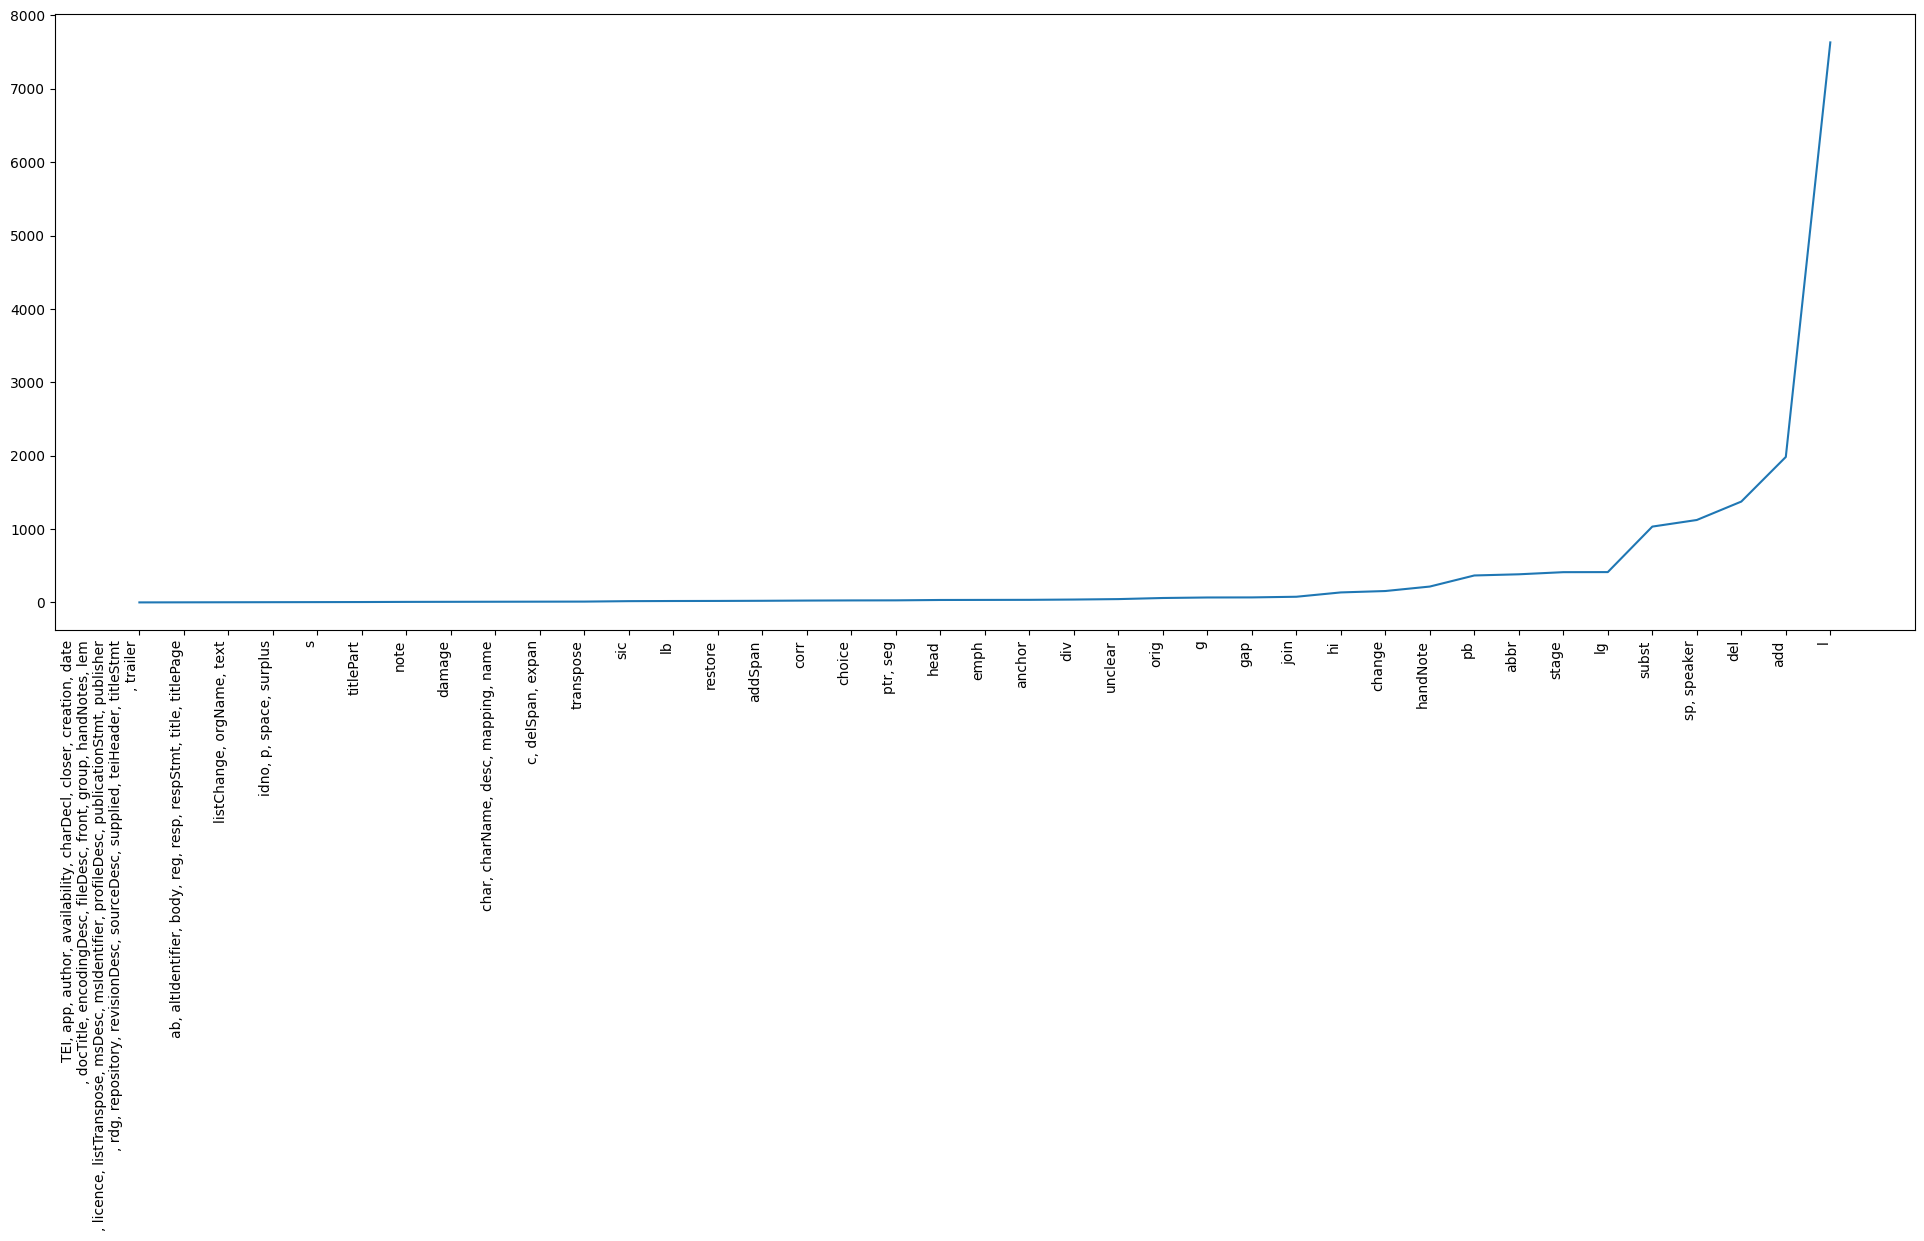

In [14]:
fig, ax = plt.subplots( figsize=(24,8))
ax.plot( x, y )
ax.tick_params(axis='x', labelrotation=90 )
for tick_label in ax.get_xticklabels():
    tick_label.set_horizontalalignment( 'right' )

I'm thinking maybe a first useful approach to 'mapping' these feature might be to generate some dispersion plots. First let's take the midpoint of each tag as the point to use for dispersion plots.

Cluster on 
branches
Absolute counts of tags / branches